1. Logistic Regression: Multiclass Classification

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


--- Multiclass Logistic Regression Results ---
Overall Accuracy: 0.9350

Classification Report:
              precision    recall  f1-score   support

         Low       0.94      1.00      0.97        60
      Medium       0.88      0.92      0.90        62
        High       0.99      0.90      0.94        78

    accuracy                           0.94       200
   macro avg       0.93      0.94      0.93       200
weighted avg       0.94      0.94      0.94       200



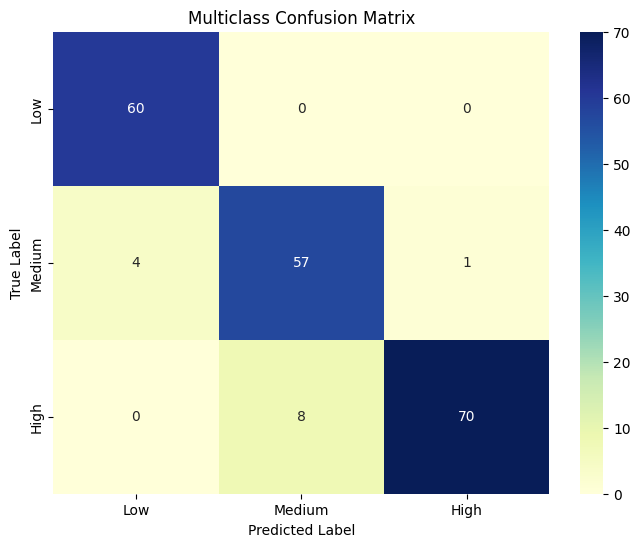

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
df_mc = pd.read_csv('sports_training_dataset.csv')
low_threshold = df_mc['training_effectiveness'].quantile(0.33)
high_threshold = df_mc['training_effectiveness'].quantile(0.66)
def categorize(val):
    if val <= low_threshold: return 0
    elif val <= high_threshold: return 1
    else: return 2
df_mc['effectiveness_label'] = df_mc['training_effectiveness'].apply(categorize)
features_mc = df_mc.select_dtypes(include=[np.number]).columns.tolist()
for col in ['training_effectiveness', 'effectiveness_label']:
    if col in features_mc: features_mc.remove(col)
X = df_mc[features_mc]
y = df_mc['effectiveness_label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
mc_log_model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)
mc_log_model.fit(X_train_scaled, y_train)
y_pred = mc_log_model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"--- Multiclass Logistic Regression Results ---")
print(f"Overall Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Low', 'Medium', 'High']))
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=['Low', 'Medium', 'High'],
            yticklabels=['Low', 'Medium', 'High'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Multiclass Confusion Matrix')
plt.show()

2. Decision Tree

--- Decision Tree Results ---
Accuracy: 0.6000

Classification Report:
              precision    recall  f1-score   support

        High       0.76      0.50      0.60        78
         Low       0.61      0.72      0.66        60
      Medium       0.48      0.61      0.54        62

    accuracy                           0.60       200
   macro avg       0.62      0.61      0.60       200
weighted avg       0.63      0.60      0.60       200



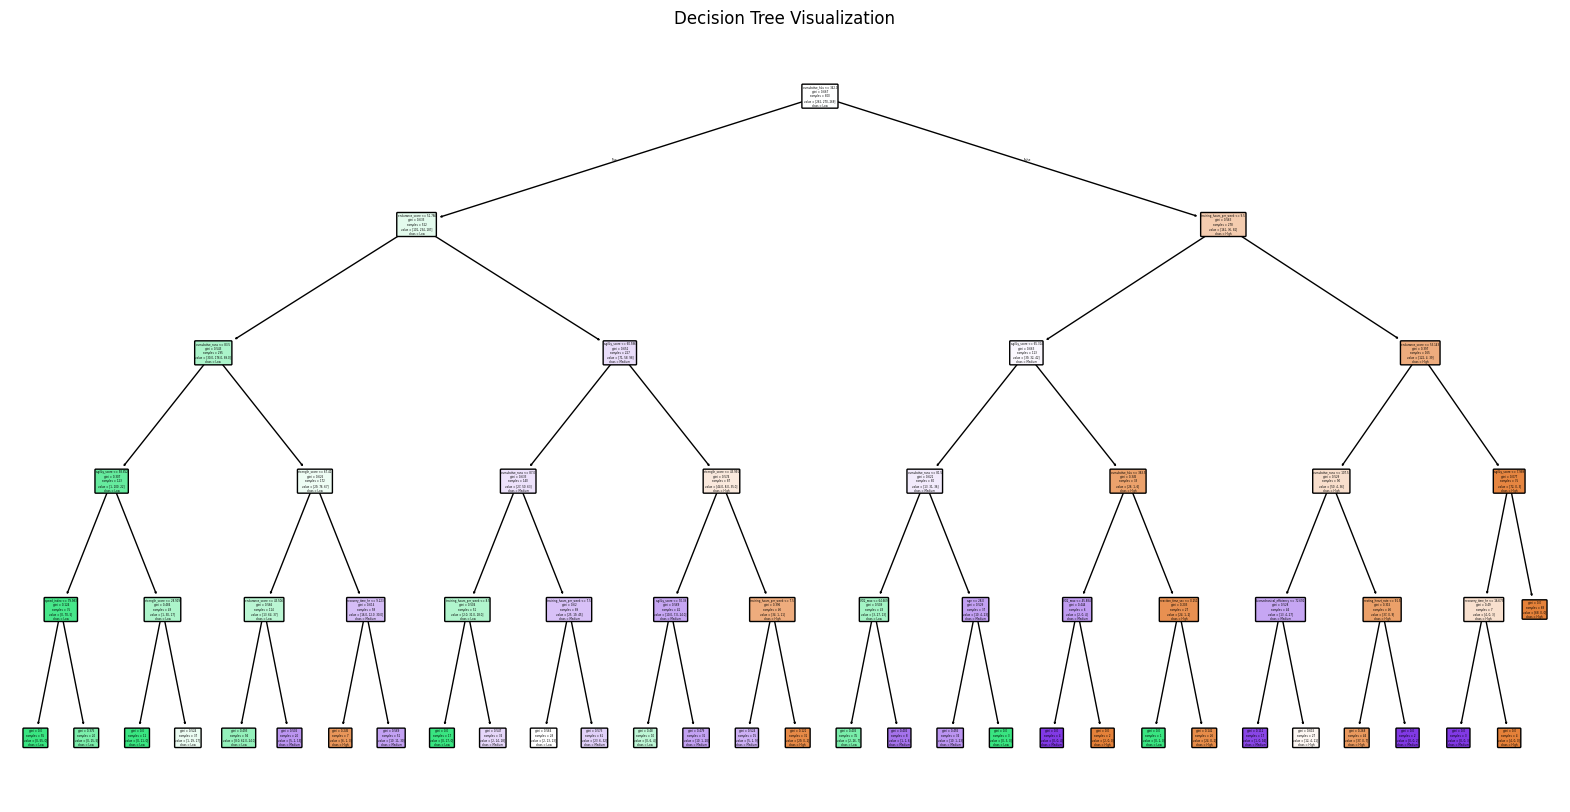

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
data_dt = pd.read_csv('sports_training_dataset.csv')
low_thresh = data_dt['training_effectiveness'].quantile(0.33)
high_thresh = data_dt['training_effectiveness'].quantile(0.66)
def label_effectiveness(val):
    if val <= low_thresh: return 'Low'
    elif val <= high_thresh: return 'Medium'
    else: return 'High'
data_dt['performance_class'] = data_dt['training_effectiveness'].apply(label_effectiveness)
dt_features = data_dt.select_dtypes(include=[np.number]).columns.tolist()
if 'training_effectiveness' in dt_features:
    dt_features.remove('training_effectiveness')
X = data_dt[dt_features]
y = data_dt['performance_class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)
y_pred = dt_model.predict(X_test)
print(f"--- Decision Tree Results ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
plt.figure(figsize=(20,10))
plot_tree(dt_model, feature_names=dt_features, class_names=['High', 'Low', 'Medium'], filled=True, rounded=True)
plt.title('Decision Tree Visualization')
plt.show()

3. Support Vector Machine(SVM)

--- SVM Classification Results ---
Accuracy: 0.8650

Classification Report:
              precision    recall  f1-score   support

         Low       0.90      0.92      0.91        60
      Medium       0.75      0.85      0.80        62
        High       0.96      0.83      0.89        78

    accuracy                           0.86       200
   macro avg       0.87      0.87      0.87       200
weighted avg       0.87      0.86      0.87       200



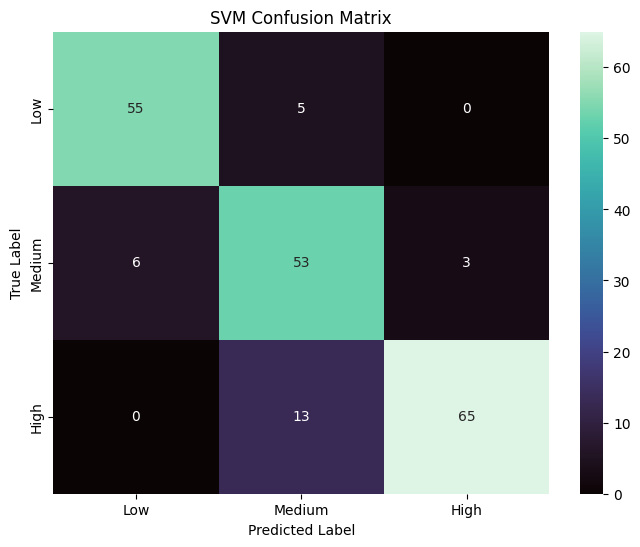

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
data_svm = pd.read_csv('sports_training_dataset.csv')
low_p = data_svm['training_effectiveness'].quantile(0.33)
high_p = data_svm['training_effectiveness'].quantile(0.66)
def categorize_performance(val):
    if val <= low_p: return 0
    elif val <= high_p: return 1
    else: return 2
data_svm['target_class'] = data_svm['training_effectiveness'].apply(categorize_performance)
features_list = data_svm.select_dtypes(include=[np.number]).columns.tolist()
for col in ['training_effectiveness', 'target_class']:
    if col in features_list: features_list.remove(col)
X = data_svm[features_list]
y = data_svm['target_class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
svm_model = SVC(kernel='rbf', C=1.0, random_state=42)
svm_model.fit(X_train_scaled, y_train)
y_pred = svm_model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"--- SVM Classification Results ---")
print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Low', 'Medium', 'High']))
plt.figure(figsize=(8, 6))
cm_svm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='mako',
            xticklabels=['Low', 'Medium', 'High'],
            yticklabels=['Low', 'Medium', 'High'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('SVM Confusion Matrix')
plt.show()

4. Random Forest

--- Random Forest Results ---
Accuracy: 0.7300

Classification Report:
              precision    recall  f1-score   support

        High       0.82      0.78      0.80        78
         Low       0.75      0.85      0.80        60
      Medium       0.59      0.55      0.57        62

    accuracy                           0.73       200
   macro avg       0.72      0.73      0.72       200
weighted avg       0.73      0.73      0.73       200



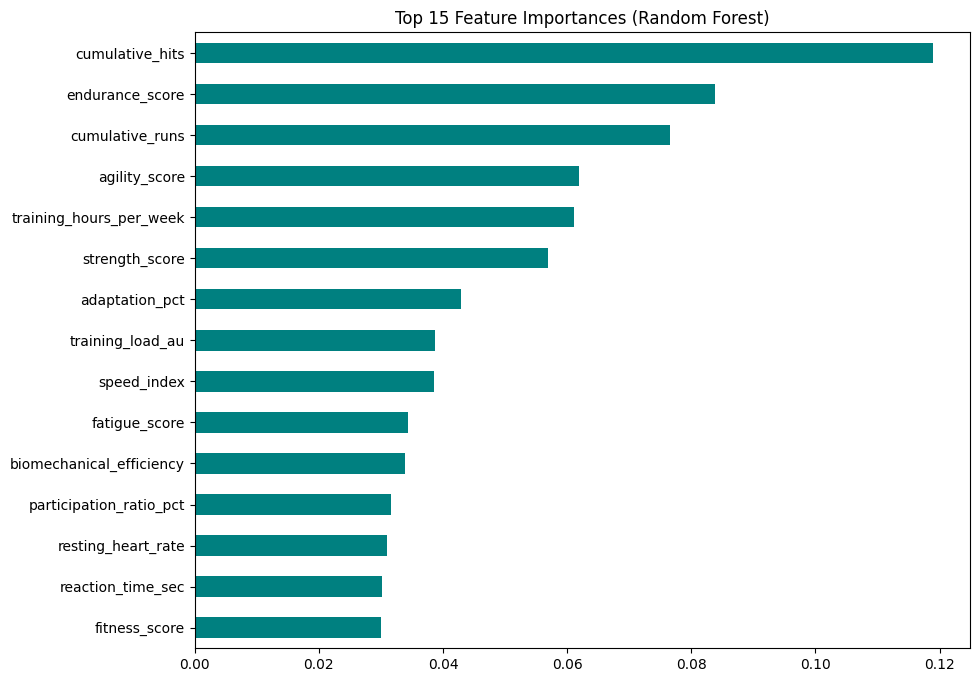

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
data_rf = pd.read_csv('sports_training_dataset.csv')
low_t = data_rf['training_effectiveness'].quantile(0.33)
high_t = data_rf['training_effectiveness'].quantile(0.66)
def categorize_rf(val):
    if val <= low_t: return 'Low'
    elif val <= high_t: return 'Medium'
    else: return 'High'
data_rf['performance_level'] = data_rf['training_effectiveness'].apply(categorize_rf)
rf_features = data_rf.select_dtypes(include=[np.number]).columns.tolist()
if 'training_effectiveness' in rf_features:
    rf_features.remove('training_effectiveness')
X = data_rf[rf_features]
y = data_rf['performance_level']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
print(f"--- Random Forest Results ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
importances = pd.Series(rf_model.feature_importances_, index=rf_features).sort_values(ascending=False)
plt.figure(figsize=(10, 8))
importances.head(15).plot(kind='barh', color='teal')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.gca().invert_yaxis()
plt.show()

5. K-means Clustering

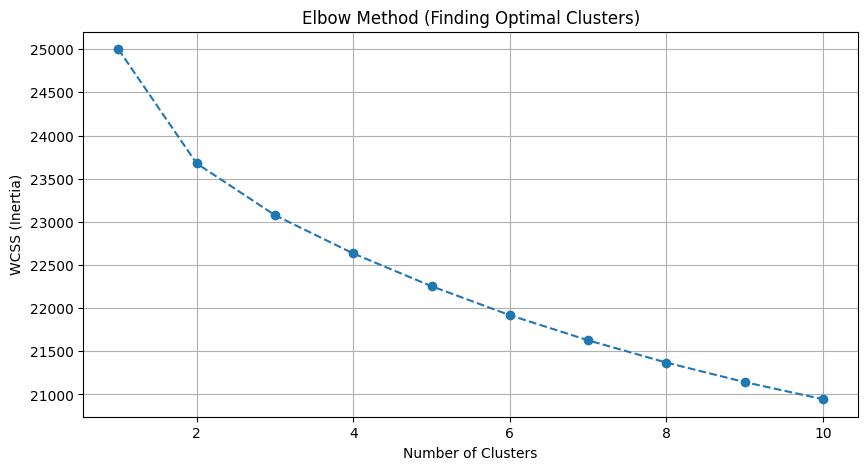

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
data_km = pd.read_csv('sports_training_dataset.csv')
numerical_cols = data_km.select_dtypes(include=[np.number]).columns.tolist()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data_km[numerical_cols])
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method (Finding Optimal Clusters)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS (Inertia)')
plt.grid(True)
plt.show()

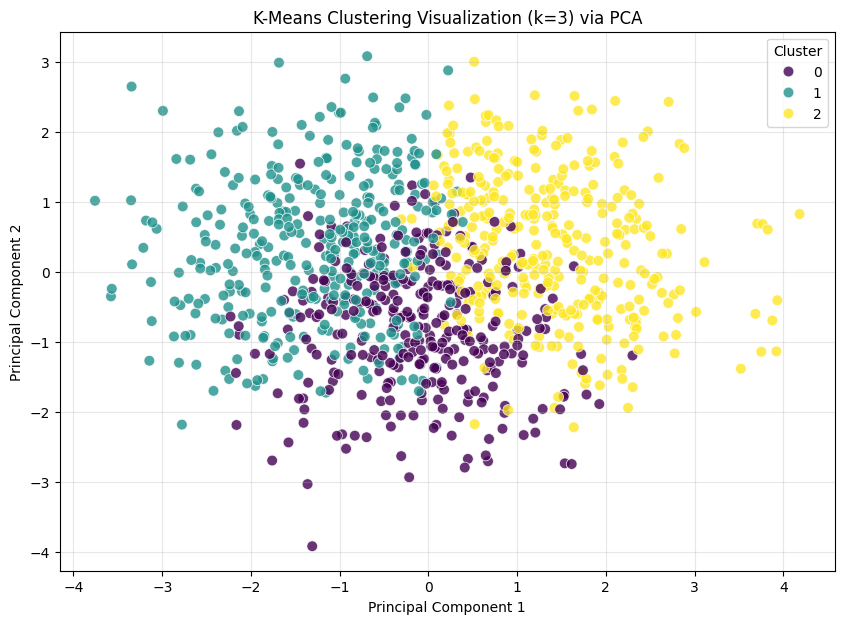

Cluster Centers (Mean Values for top 5 features):


,age,height_cm,weight_kg,resting_heart_rate,max_heart_rate
Cluster,,,,,
0,20.509868,175.687500,75.690789,71.828947,188.036184
1,23.209169,175.796562,70.163324,78.464183,182.578797
2,21.855908,173.100865,68.172911,74.100865,186.126801


In [6]:
optimal_k = 3
kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(X_scaled)
data_km['Cluster'] = clusters
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=clusters, palette='viridis', s=60, alpha=0.8)
plt.title(f'K-Means Clustering Visualization (k={optimal_k}) via PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True, alpha=0.3)
plt.show()
print("Cluster Centers (Mean Values for top 5 features):")
profile = data_km.groupby('Cluster')[numerical_cols].mean().iloc[:, :5]
display(profile)

--- K-Means 'Accuracy' (Cluster-to-Label Mapping) ---
Calculated Accuracy: 0.6870


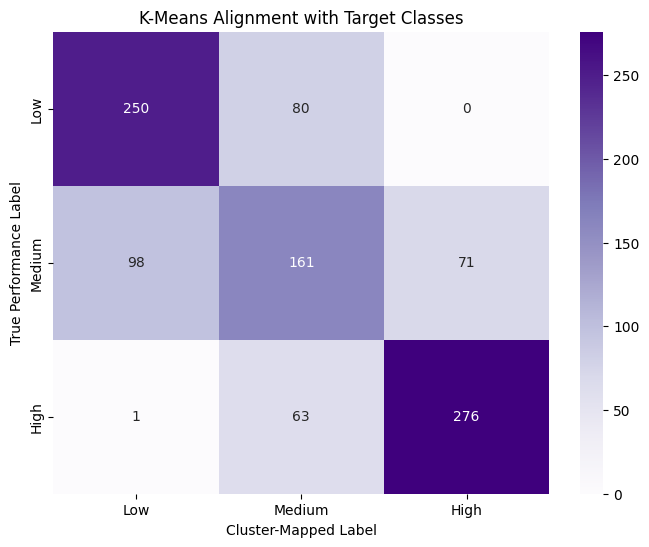

In [7]:
from sklearn.metrics import accuracy_score
from scipy.stats import mode
label_map = {'Low': 0, 'Medium': 1, 'High': 2}
y_true = data_km['training_effectiveness'].apply(categorize_rf).map(label_map)
cluster_labels = np.zeros_like(clusters)
for i in range(optimal_k):
    mask = (clusters == i)
    if np.any(mask):
        cluster_labels[mask] = mode(y_true[mask])[0]
km_accuracy = accuracy_score(y_true, cluster_labels)
print(f"--- K-Means 'Accuracy' (Cluster-to-Label Mapping) ---")
print(f"Calculated Accuracy: {km_accuracy:.4f}")
plt.figure(figsize=(8, 6))
cm_km = confusion_matrix(y_true, cluster_labels)
sns.heatmap(cm_km, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Low', 'Medium', 'High'],
            yticklabels=['Low', 'Medium', 'High'])
plt.xlabel('Cluster-Mapped Label')
plt.ylabel('True Performance Label')
plt.title('K-Means Alignment with Target Classes')
plt.show()

In [9]:
import joblib
joblib.dump(mc_log_model, "sports_model.pkl")

['sports_model.pkl']